# Phase and Gain of Annual Harmonic versus mean local temperature
Below I show that over a wide range of climates, you see a robust decrease in the Gain (amplitude of surface temperature / amplitude of SW radiation) with warming. Also, the gradient appears to be approximately constant at all latitudes.

I first do this over a range of latitudes.

## Two layer equations

Surface Energy budget:
$$C_s\frac{\partial T_s}{\partial t} = (1-\mathrm{f})(1-A)SW^{\downarrow} + \lambda (T_a - T_s) - \Lambda T_a$$
where:
* $C_s$ is surface heat capacity
* $T_s$ is surface temperature
* $T_a$ is lowest model level temperature
* $t$ is time
* $f$ is fraction of shortwave at top of atmosphere $SW^{\downarrow}$ absorbed by the atmosphere
* $A$ is surface albedo
* $\lambda$ is linear feedback parameter as used in e.g., [barsugli_1998](https://agupubs.onlinelibrary.wiley.com/doi/10.1002/jame.20049)
* $\Lambda$ is a residual feedback parameter because upward flux of energy from surface ($LW^{\uparrow} - LW^{\downarrow} + SH^{\uparrow} + LH^{\uparrow}$) is not exactly equal to $\lambda (T_s - T_a)$ in my simulations.

Atmospheric energy budget (linearization of equation (1) in [donohoe_2013](https://link.springer.com/article/10.1007/s00382-013-1843-4)):
$$C_a(\beta+\mu)\frac{\partial T_a}{\partial t} = \lambda (T_s - T_a) - B T_a + \Lambda T_a - B_{\mathrm{adv}}T_a + \mathrm{f}SW^{\downarrow}$$
where:
* $C_a=c_p(p_s-p_t)/g$ is the dry contribution of the atmospheric heat capacity e.g., [cronin_2013](https://agupubs.onlinelibrary.wiley.com/doi/10.1002/jame.20049) equation (8)
* $\beta$ is empirical parameter relating mass weighted column mean temperature to lowest model level temperature.
* $\mu$ is the moisture contribution to the atmospheric heat capacity.
* $B$ is the change in outgoing longwave radiation at the top of the atmosphere per unit change in lowest model level temperature.
* $B_{\mathrm{adv}}$ is an empirically obtained relationship between the meridional advection and the local lowest model level temperature.

Some of the empirical parameters are complex (i.e., have phase parameters too) in order to make these equations accurate.

In [1]:
import copy
import sys
import os
import re
import inspect
import scipy.optimize

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.season_annual_harmonic import get_phase_amp
from isca_tools.thesis.surface_flux_taylor_2layer import get_p_eff, get_temp_from_sphum_sat, get_sensible_heat, \
    get_latent_heat
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic, get_fit_coef_complex
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

from jobs.thesis_season.column.utils import get_flux

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

## Single Latitude
Now I look in more detail at a single latitude. First I see if theoretically I can replicate the absolute values and trends of the phase and gain using empirically found parameters and the two layer energy budget model.

I also do a decomposition of the contributions to the variation in seasonality with mean temperature. For decomposition, I consider $\lambda$ and then dimensional quantities i.e., $B/\lambda$, $\lambda_a/\lambda$, etc.

In [35]:
from jobs.thesis_season.publish_figs.load import load_ds_all, width, day_seconds, exclude_params, params_all, label_temp
from jobs.thesis_season.publish_figs.energy_budget_empirical import get_approx_flux_atmos, get_empirical_params, \
    get_approx_mse_tend, get_heat_cap_lambda_eff
from jobs.thesis_season.publish_figs.xr_funcs import get_fit_complex_xr, apply_linear_zero_mean_xr, get_fourier_fit_xr, spline_deriv_periodic_xr
exp_name = 'advect'
ds = load_ds_all(exp_name)

Loaded dataset from:
/Users/joshduffield/Documents/StAndrews/Isca/jobs/thesis_season/publish_figs/processed_data/ds_advect.nc


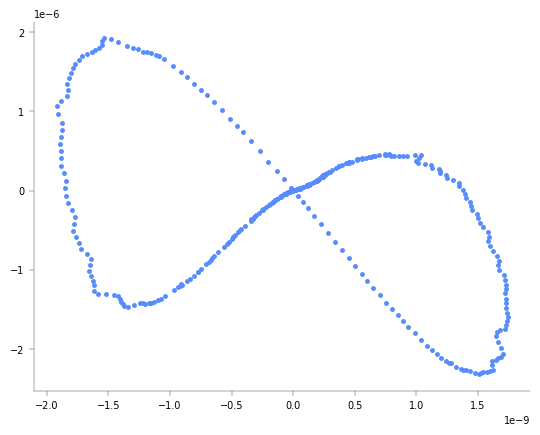

In [48]:
var = (ds.p_surf-ds.p_surf.mean(dim='time'))
var2 = spline_deriv_periodic_xr(ds.time * day_seconds,
                                                    ds.q_atm)
plt.scatter(var2.isel(odp=0), (var*var2).isel(odp=0))

In [16]:
exclude_params_use = exclude_params['advect' if exp_name == 'advect' else 'column']
feedback_params = get_empirical_params(ds, exclude_params=exclude_params_use)

In [17]:
arg_names = list(inspect.signature(get_heat_cap_lambda_eff).parameters.keys())
arg_use = {key: feedback_params[key] for key in arg_names if key in feedback_params}
arg_use['heat_cap_surf'] = ds.heat_cap_surf
arg_use['pressure_heat_cap_atmos_calc'] = ds.p_integ_calc.mean(dim='time')
arg_use['sw_abs'] = ds.sw_abs
arg_use['albedo'] = ds.albedo
ds['lambda_eff_theory'], ds['heat_cap_eff_theory'] = get_heat_cap_lambda_eff(**arg_use)
ds['coef_phase_theory'], ds['coef_amp_theory'] = get_phase_amp(ds.coef_sw_amp, ds.omega,
                                                               ds['heat_cap_eff_theory'], ds['lambda_eff_theory'])
for key in arg_use:
    if 'phase' in key:
        arg_use[key] = arg_use[key] * 0
ds['lambda_eff_theory_no_phase'], ds['heat_cap_eff_theory_no_phase'] = get_heat_cap_lambda_eff(**arg_use)
ds['coef_phase_theory_no_phase'], ds['coef_amp_theory_no_phase'] = get_phase_amp(ds.coef_sw_amp, ds.omega,
                                                               ds['heat_cap_eff_theory_no_phase'], ds['lambda_eff_theory_no_phase'])

In [18]:
feedback_params_dim = feedback_params.copy()
for key in feedback_params:
    if (key == 'B') or ('lambda' in key) and (key != 'lambda_const'):
        feedback_params_dim[key] = feedback_params[key] / feedback_params['lambda_const']


def isolate_phase_amp_cont(ds, param, feedback_params=feedback_params_dim, vary_dim='odp', vary_dim_ref_val=1.5,
                           no_phase: bool = False, only_lambda_eff=False, only_heat_cap_eff=False):
    # no_phase - set all phase parameters to zero
    # only_eff parameters: Only make one of lambda or heat_cap vary with param, still impact both amplitude and phase though
    # param is a string or list of strings, make list here
    if isinstance(param, str):
        param = [param]
    # Way to isolate the effect of a single parameter on the various seasonality factors
    arg_use = {key: feedback_params[key] for key in arg_names if key in feedback_params}
    arg_use['heat_cap_surf'] = ds.heat_cap_surf
    arg_use['pressure_heat_cap_atmos_calc'] = ds.p_integ_calc.mean(dim='time')
    arg_use['sw_abs'] = ds.sw_abs
    arg_use['albedo'] = ds.albedo
    for key in arg_use:
        # if key in ['lambda_const', 'lambda_a', 'mu', 'lambda_adv', 'B']:
        #     continue
        if key in param:
            if ('phase' in key) and no_phase:
                arg_use[key] = arg_use[key] * 0
            continue
        elif isinstance(arg_use[key], xr.DataArray) and (vary_dim in arg_use[key].dims):
            arg_use[key] = arg_use[key].sel({vary_dim: vary_dim_ref_val})
            if ('phase' in key) and no_phase:
                arg_use[key] = arg_use[key] * 0


    # Re-dimensionalize the parameters
    # It is the dimensionless parameter that I am changing, not the raw value
    for key in ['B', 'lambda_a', 'lambda_adv']:
        arg_use[key] = arg_use[key] * arg_use['lambda_const']

    lambda_eff_theory, heat_cap_eff_theory = get_heat_cap_lambda_eff(**arg_use)

    if only_lambda_eff or only_heat_cap_eff:
        # Only make one of lambda or heat_cap equal to ref value, still impact both amplitude and phase though
        for key in arg_use:
            if isinstance(arg_use[key], xr.DataArray) and (vary_dim in arg_use[key].dims):
                arg_use[key] = arg_use[key].sel({vary_dim: vary_dim_ref_val})
        lambda_eff_theory_ref, heat_cap_eff_theory_ref = get_heat_cap_lambda_eff(**arg_use)
        if only_lambda_eff:
            heat_cap_eff_theory = heat_cap_eff_theory * 0 + heat_cap_eff_theory_ref
        if only_heat_cap_eff:
            lambda_eff_theory = lambda_eff_theory * 0 + lambda_eff_theory_ref

    coef_phase_theory, coef_amp_theory = get_phase_amp(ds.coef_sw_amp, ds.omega,
                                                       heat_cap_eff_theory, lambda_eff_theory)
    return lambda_eff_theory, heat_cap_eff_theory, coef_phase_theory, coef_amp_theory

In [19]:
odp_ref = 1.5
phase_info = {key2: {key: {} for key in ['lambda_eff', 'heat_cap_eff', 'coef_phase', 'coef_amp']} for key2 in ['full', 'simple']}
for key2 in phase_info:
    for key in phase_info[key2]:
        phase_info[key2][key]['simulated'] = ds[key]
        phase_info[key2][key]['theory'] = ds[f"{key}_theory_no_phase"] if key2=='simple' else ds[f"{key}_theory"]
vars_isolate = {'full': [key for key in params_all if ((key not in exclude_params_use) and (key != 'sw_abs'))],
                'simple': ['lambda_const', 'B', 'mu', 'coef_amp_col']}

# NOTE!! For simplicity, I only consider how B and lambda affect lambda_eff, and mu and coef_amp_col affect heat_cap_eff in simple mode
for key2 in phase_info:
    for key in vars_isolate[key2]:
        phase_info[key2]['lambda_eff'][key], phase_info[key2]['heat_cap_eff'][key], phase_info[key2]['coef_phase'][key], \
            phase_info[key2]['coef_amp'][key] = \
            isolate_phase_amp_cont(ds, key, vary_dim_ref_val=odp_ref,
                                   no_phase=key2=='simple',
                                   only_lambda_eff=(key in ['B', 'lambda_const']) if key2=='simple' else False,
                                   only_heat_cap_eff=(key in ['mu', 'coef_amp_col']) if key2=='simple' else False)

# Residual is difference between full theory and linear sum of all components
for key2 in phase_info:
    for key in phase_info[key2]:
        phase_info[key2][key]['theory_linear'] = sum(var - var.sel(odp=odp_ref) for key2, var in phase_info[key2][key].items() if
                                                     key2 not in {"simulated", "theory"})
        phase_info[key2][key]['residual'] = phase_info[key2][key]['theory'] - phase_info[key2][key]['theory_linear']
        phase_info[key2][key]['theory_linear'] = phase_info[key2][key]['theory_linear'] + phase_info[key2][key]['theory'].sel(odp=odp_ref)


# Include non linear combination of \lambda and \mu - makes little difference
# key = 'lambda_const_mu'
# phase_info['lambda_eff'][key], phase_info['heat_cap_eff'][key], phase_info['coef_phase'][key], phase_info['coef_amp'][key] = \
#         isolate_phase_amp_cont(ds_sl, ['lambda_const', 'mu'], zero_phase_a=False in exp_dir, vary_dim_ref_val=odp_ref)

### Plot with all isolated terms
This can be done in full theory or in simple mode.

Two different methods:
* Full: Contains all the phase parameters required by error analysis. Then considers how all parameters independently vary with warming. Add these together to give theory_linear. This is close to simulated and purpose is to show with all parameters, get good fit.
* Simple: Set all phase parameters to zero, this means offset for all climates. Then linear theory only considers the two most significant terms that vary for $\lambda_{eff}$ and $C_{eff}$. And only consider their effect on one term. Then add all these together to get final theory. Purpose of this is that is simple, get trend broadly correct even if systematic offset. Use this for algebra.

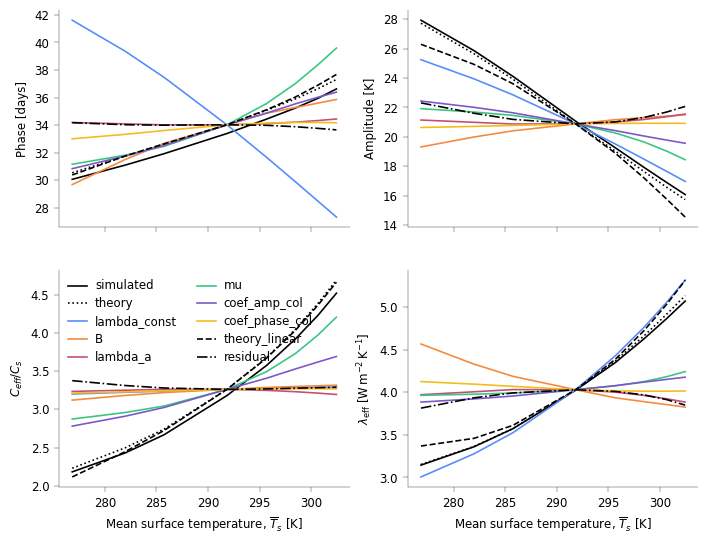

In [20]:
method = 'full'
colors_use = {'simulated': 'k', 'theory': 'k', 'residual': 'k'}
for i, key in enumerate(vars_isolate[method]):
    colors_use[key] = 'k' if key in ['simulated', 'theory'] else f"C{i}"
linestyle_use = {key: None for key in phase_info[method]['lambda_eff']}
linestyle_use['theory'] = ':'
linestyle_use['theory_linear'] = '--'
colors_use['theory_linear'] = 'k'
linestyle_use['lambda_const_mu'] = '-'
colors_use['lambda_const_mu'] = 'C2'
linestyle_use['residual'] = '-.'

fig, ax = plt.subplots(2, 2, sharex=True)
fig_resize(fig, width['two_col'] * 1.5)
ax = ax.flatten()
for i, key in enumerate(phase_info[method]['coef_phase']):
    if key in ['lambda_const_mu']:
        continue
    # if key not in ['lambda_const', 'theory', 'simulated']:
    #     continue
    var = [phase_info[method]['coef_phase'][key] / ds.omega / day_seconds, phase_info[method]['coef_amp'][key],
           phase_info[method]['heat_cap_eff'][key] / ds.heat_cap_surf, phase_info[method]['lambda_eff'][key]]
    for j in range(len(var)):
        # if (np.abs(var[j]-var[j].sel(odp=odp_ref))/var[j].sel(odp=odp_ref)).max() < 0.03:
        #     continue
        ax[j].plot(ds.temp_surf.mean(dim='time'), var[j],
                   label=key, color=colors_use[key], linestyle=linestyle_use[key])
ax[0].set_ylabel('Phase [days]')
ax[1].set_ylabel(r'Amplitude [K]')
ax[2].set_ylabel('$C_{eff}/C_s$')
ax[3].set_ylabel(r'$\lambda_{\mathrm{eff}}$ [$\mathrm{W\,m^{-2}\,K^{-1}}$]')
ax[2].set_xlabel(label_temp)
ax[3].set_xlabel(label_temp)
# ax[0].set_xlim(287, 310)
update_linewidth(fig)
ax[-2].legend(ncol=2)
# fig.suptitle(f'Lat = {ds.lat.values:.1f}$\degree$ | Depth = {ds_sl.depth:.1f} m', y=0.96)
update_fontsize(fig, 7.2)
plt.show()
# savefig(fig)

#### Plot figure

Below I show a combined version of the figure above for the paper. It includes both theory results, and then the dominant two terms for the simple methodology.

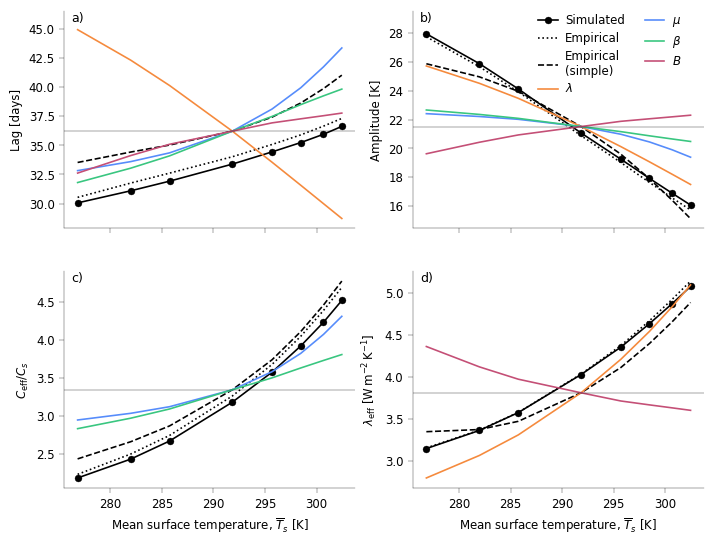

In [21]:
colors_use2 = colors_use.copy()
colors_use2['mu'] = 'C0'
colors_use2['lambda_const'] = 'C1'
colors_use2['coef_amp_col'] = 'C3'
colors_use2['B'] = 'C2'
labels_use = {'simulated': 'Simulated', 'theory_linear': 'Empirical\n(simple)', 'lambda_const': r'$\lambda$',
              'mu': r'$\mu$', 'theory': 'Empirical',
              'coef_amp_col': '$\\beta$', 'B': '$B$'}
fig, ax = plt.subplots(2, 2, sharex=True)
fig_resize(fig, width['two_col'] * 1.5)
ax = ax.flatten()
for i, key in enumerate(['simulated', 'theory', 'theory_linear', 'lambda_const', 'mu', 'coef_amp_col', 'B']):
    key2 = 'full' if key in ['simulated', 'theory'] else 'simple'
    var = [phase_info[key2]['coef_phase'][key] / ds.omega / day_seconds,
           phase_info[key2]['coef_amp'][key],
           phase_info[key2]['heat_cap_eff'][key] / ds.heat_cap_surf, phase_info[key2]['lambda_eff'][key]]
    for j in range(len(var)):
        if (j == 2 and key in ['lambda_const', 'B']) or (j == 3 and key in ['mu', 'coef_amp_col']):
            continue
        ax[j].plot(ds.temp_surf.mean(dim='time'), var[j],
                   label=labels_use[key], color=colors_use2[key], linestyle=linestyle_use[key],
                   marker='.' if key == 'simulated' else None, markersize=10)
ax[0].set_ylabel('Lag [days]')
ax[1].set_ylabel(r'Amplitude [K]')
ax[2].set_ylabel(r'$C_{\mathrm{eff}}/C_s$')
ax[3].set_ylabel(r'$\lambda_{\mathrm{eff}}$ [$\mathrm{W\,m^{-2}\,K^{-1}}$]')
ax[2].set_xlabel(label_temp)
ax[3].set_xlabel(label_temp)
update_linewidth(fig)
for j in range(len(var)):
    ax[j].axhline(var[j].sel(odp=odp_ref), color='k', lw=ax_linewidth)
ax[1].legend(ncol=2, bbox_to_anchor=(0.4, 1.03), loc="upper left")
# fig.suptitle(f'Lat = {ds_sl.lat.values:.1f}$\degree$ | Depth = {ds_sl.depth:.1f} m', y=0.96)
update_fontsize(fig, 7.2)
# if 'column' not in exp_dir:
#     ax[0].set_xlim(278, 303)
#     ax[0].set_ylim(23.5, 34)
#     ax[1].set_ylim(15, 24.5)
#     ax[2].set_ylim(2, 4)
#     ax[3].set_ylim(3.4, 5.9)
# else:
#     ax[0].set_xlim(287, 310)
# ax[0].set_ylim(ax[0].get_ylim()[0], 42)
# ax[1].set_ylim(ax[1].get_ylim()[0], 29.5)
if 'advect' in exp_name:
    ax[0].set_ylim(ax[0].get_ylim()[0], 27)
    ax[1].set_ylim(ax[1].get_ylim()[0], 23)
else:
    ax[0].set_ylim(ax[0].get_ylim()[0], 46.5)
    ax[1].set_ylim(ax[1].get_ylim()[0], 29.5)
label_subplots(fig, ax, pos_y=-0.5, box_alpha=0)
plt.show()
# savefig(fig, f"z_result_{exp_name}")

#### Rate of change
Below I print the gradients with respect to mean surface temperature of the above figure.

In [22]:
for key in ['coef_phase', 'coef_amp', 'heat_cap_eff', 'lambda_eff']:
    for key2 in ['simulated', 'theory', 'theory_linear']:
        key3 = 'full' if key2 in ['simulated', 'theory'] else 'simple'
        var = np.polyfit(ds.temp_surf.mean(dim='time'), phase_info[key3][key][key2], deg=1)
        var_fit = np.polyval(var, ds.temp_surf.mean(dim='time'))
        var = var[0]
        if 'phase' in key:
            var = var / ds.omega / day_seconds
        if key in ['heat_cap_eff', 'lambda_eff']:
            var = 100 * var / phase_info['full'][key]['simulated'].sel(odp=odp_ref)
        print(f"{key.capitalize()} | {key2} | {var:.3f}")
        # Compute variance explained
        # ss_res = np.sum((phase_info[key][key2] - var_fit)**2)
        # ss_tot = np.sum((phase_info[key][key2] - np.mean(var_fit))**2)
        #
        # nonlinear_fraction = ss_res / ss_tot if ss_tot > 0 else np.nan
        # r_squared = 1 - nonlinear_fraction
        # print(r_squared.values)

Coef_phase | simulated | 0.255
Coef_phase | theory | 0.260
Coef_phase | theory_linear | 0.280
Coef_amp | simulated | -0.472
Coef_amp | theory | -0.477
Coef_amp | theory_linear | -0.427
Heat_cap_eff | simulated | 2.875
Heat_cap_eff | theory | 3.015
Heat_cap_eff | theory_linear | 2.852
Lambda_eff | simulated | 1.897
Lambda_eff | theory | 1.949
Lambda_eff | theory_linear | 1.528


### Why does $\beta$ increase with warming
Below I plot a lapse rate metric versus surface temperature. For cold climates, the lapse rate increases with temperature. I think this is because cold climates have a temperature inversion, so the hotter it is, the more you remove this, and hence the lapse rate increases.
For hot climates, you have no temperature inversion and lapse rate is approximately moist adiabatic. Moist adiabatic lapse rate decreases with warming, hence the trend for the warmest simulation.

If no temperature inversion, may relate to rate of decrease of lapse rate with warming or to what extent convection is active.

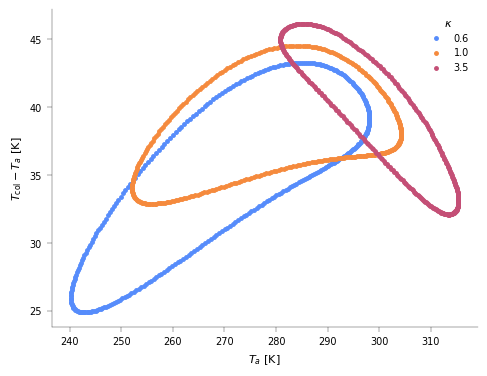

In [23]:
fig, ax = plt.subplots(1, 1, sharex=True)
fig_resize(fig, width['two_col'])
var = ds.temp_atm - ds.temp_col
ax.scatter(ds.temp_atm.isel(odp=0), var.isel(odp=0), label=ds.odp[0].values)
ax.scatter(ds.temp_atm.isel(odp=2), var.isel(odp=2), label=ds.odp[2].values)
ax.scatter(ds.temp_atm.isel(odp=-1), var.isel(odp=-1), label=ds.odp[-1].values)
ax.legend(title=r'$\kappa$')
ax.set_xlabel('$T_a$ [K]')
ax.set_ylabel(r'$T_{\text{col}} - T_{a}$ [K]')
plt.show()

### Harmonic amplitude ratio
Justification for our chosen latitude kis from surface shortwave radiation. But surface temperature second harmonic actually quite important, so maybe mention this somewhere.

In [11]:
print((np.abs(get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=2, pad_coefs_phase=True)[1].sel(harmonic=2)) /
       ds['coef_sw_amp']).values[0] * 100)
var = np.abs(get_fourier_fit_xr(ds.time, ds.temp_surf, n_harmonics=2, pad_coefs_phase=True)[1])
print((var.sel(harmonic=2) / var.sel(harmonic=1)).values * 100)

1.0662693265392664
[ 9.02816163  7.90144947  8.86299695  8.45838074  8.92189055 10.2187746
 10.26605798 11.02130236]


In [12]:
# Sanity check that optical depth calculation is correct
print(ds.odp_surf.sel(odp=1).values)
print(isca_tools.utils.radiation.opd_lw_gray(43.25, pressure_ref=ds.p_ref, pressure=ds.p_surf).values[
          0, 0])

3.8870303787232867
3.9973266


### Decomposition of Advection

Below I split the MSE advection up into dry and moist parts. We see that this parameter increases with warming at a faster rate that the overall $\lambda$. And it is the dry advection that increases at a faster rate than the moist component.

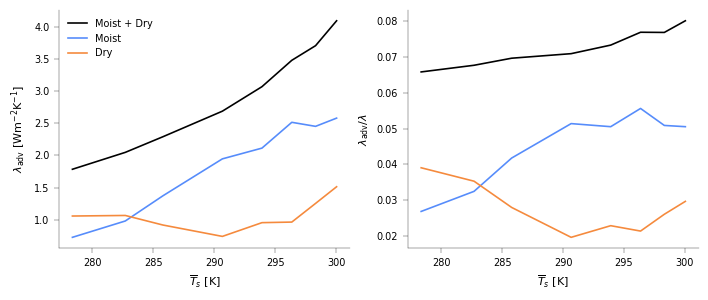

In [13]:
fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, width['two_col'] * 1.5)
for i, var in enumerate([feedback_params, feedback_params_dim]):
    # Need to multiply by cos as these real parts are what are added together to get the overall real part of lambda
    ax[i].plot(ds.temp_surf.mean(dim='time'), var['lambda_adv'] * np.cos(var['coef_phase_adv']), color='k',
               label='Moist + Dry')
    ax[i].plot(ds.temp_surf.mean(dim='time'), var['lambda_adv_moist'] * np.cos(var['coef_phase_adv_moist']),
               color='C0', label='Moist')
    ax[i].plot(ds.temp_surf.mean(dim='time'), var['lambda_adv_dry'] * np.cos(var['coef_phase_adv_dry']), color='C1',
               label='Dry')
    # ax[i].plot(ds_sl.temp_surf.mean(dim='time'), var['lambda_adv_dry']*np.cos(var['coef_phase_adv_dry'])+var['lambda_adv_moist']*np.cos(var['coef_phase_adv_moist']), color='C2')
update_linewidth(fig)
ax[0].legend()
ax[0].set_ylabel(r"$\lambda_{\text{adv}}$ [Wm$^{-2}\text{K}^{-1}$]")
ax[1].set_ylabel(r"$\lambda_{\text{adv}}/\lambda$")
ax[0].set_xlabel(r'$\overline{T}_s$ [K]')
ax[1].set_xlabel(r'$\overline{T}_s$ [K]')
plt.show()

In [26]:
0.99*270-0.005*230

266.15000000000003

In [25]:
0.99*270

267.3